In [128]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_all_user_json_curves_single(json_dir, max_event=650, model = None):
    """
    Plot average EER (and AUC optionally) curves for all JSON files inside a folder.
    Each JSON file represents a model experiment, and each contributes one curve.

    Parameters
    ----------
    json_dir : str or Path
        Path to the folder containing JSON result files (e.g. 'Training/Results/train_all_user_1DCNN')
    max_event : int
        Maximum number of events to display on the x-axis
    """
    json_dir = Path(json_dir)
    plt.figure(figsize=(8, 5))

    for json_file in json_dir.glob("*.json"):
        try:
            # Set multiplier based on file name
            if "traj" in json_file.stem.lower():
                multiplier = 25.22
            elif "PeakClick" in json_file.stem:
                multiplier = 19.3
            else:
                multiplier = 1.0

            # Skip empty files
            if json_file.stat().st_size == 0:
                print(f"[SKIP] Empty file: {json_file.name}")
                continue

            # Load JSON data
            with open(json_file, "r") as f:
                data = json.load(f)

            # Aggregate per-user results
            user_eers = []
            ns = None
            for user, records in data.items():
                n_vals = []
                eers = []
                for k, v in records.items():
                    n_vals.append(v["n"])
                    eers.append(v["EER"])
                user_eers.append(eers)
                ns = n_vals  # same for all users

            # Compute average EER across users
            user_eers = np.array(user_eers)
            avg_eer = np.mean(user_eers, axis=0)

            # Compute event x-axis
            events = np.array(ns) * multiplier
            mask = events <= max_event
            events = events[mask]
            avg_eer = avg_eer[mask]

            plt.plot(events, avg_eer, marker='o', linewidth=1.8, label=json_file.stem)

        except Exception as e:
            print(f"[ERROR] Failed to process {json_file.name}: {e}")
            continue

    plt.xlabel("Events", fontsize=12)
    plt.ylabel("Average EER", fontsize=12)
    plt.title(f"{model} (Max = {max_event})", fontsize=13, weight='bold')
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()



In [129]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# color fixed
chunk_color_map = {
    "PeakClick": "tab:blue",
    "10": "tab:blue",
    "15": "tab:orange",
    "30": "tab:green",
    "60": "tab:red",
    "120": "tab:purple",
    "300": "tab:brown"
}

def plot_chunk_json_curves(json_dir, max_event=650, model=None):
    json_dir = Path(json_dir)
    plt.figure(figsize=(8, 5))

    for json_file in json_dir.glob("*.json"):
        try:
            name = json_file.stem

            if "PeakClick" in name:
                multiplier = 19.3
                chunk_key = "PeakClick"
            else:
                match = re.search(r"ChunkSize(\d+)", name)
                chunk_key = match.group(1) if match else None
                multiplier = float(chunk_key) if chunk_key else 1.0

            color = chunk_color_map.get(chunk_key, "black")

            with open(json_file, "r") as f:
                data = json.load(f)

            n = np.array(data["n"])
            avg_eer = np.array(data["avg_eer"])
            events = n * multiplier

            mask = events <= max_event
            events = events[mask]
            avg_eer = avg_eer[mask]

            plt.plot(events, avg_eer, marker='o', linewidth=1.8,
                     color=color, label=name)

        except Exception as e:
            print(f"[ERROR] Failed to process {json_file.name}: {e}")
            continue

    plt.xlabel("Events", fontsize=12)
    plt.ylabel("Average EER", fontsize=12)
    plt.title(f"{model} (Chunk Size Experiments)", fontsize=13, weight="bold")
    plt.grid(True, linestyle="--", alpha=0.6)

    # ---- chunk size ranking ----
    handles, labels = plt.gca().get_legend_handles_labels()

    def extract_size(label):
        if "PeakClick" in label:
            return -1
        m = re.search(r"ChunkSize(\d+)", label)
        return int(m.group(1)) if m else 999999

    sorted_pairs = sorted(zip(handles, labels), key=lambda x: extract_size(x[1]))
    sorted_handles, sorted_labels = zip(*sorted_pairs)

    plt.legend(sorted_handles, sorted_labels, fontsize=10)

    plt.tight_layout()
    plt.show()


In [130]:
import re
chunk_color_map = {
    "PeakClick": "tab:blue",
    "10": "tab:blue",
    "15": "tab:orange",
    "30": "tab:green",
    "60": "tab:red",
    "120": "tab:purple",
    "300": "tab:brown"
}


def parse_chunk_size_from_filename(fname):
    """
    ChunkSize120BinaryViT.json -> "120"
    """
    match = re.search(r"ChunkSize(\d+)", fname)
    if match is None:
        raise ValueError(f"Cannot parse chunk size from {fname}")
    return match.group(1)   

import json
import numpy as np

def load_avg_eer_from_json(json_path, chunk_size, max_event=None):
    """
    Compute average EER vs #events (NOT images).
    """
    with open(json_path, "r") as f:
        data = json.load(f)

    eer_by_event = {}

    for user, records in data.items():
        for n_str, metrics in records.items():
            n_img = int(n_str)
            n_event = n_img * chunk_size   

            if max_event is not None and n_event > max_event:
                continue

            eer = metrics.get("EER", None)
            if eer is None:
                continue

            eer_by_event.setdefault(n_event, []).append(eer)

    events = sorted(eer_by_event.keys())
    avg_eer = [np.mean(eer_by_event[e]) for e in events]

    return np.array(events), np.array(avg_eer)

import os
import matplotlib.pyplot as plt

import os
import matplotlib.pyplot as plt

def plot_avg_eer_curves(base_dir, max_event=650, model=None):
    plt.figure(figsize=(8, 5))

    curves = []

    for fname in os.listdir(base_dir):
        if not fname.endswith(".json"):
            continue

        chunk = parse_chunk_size_from_filename(fname)  # "10", "15", ...
        if chunk not in chunk_color_map:
            continue

        json_path = os.path.join(base_dir, fname)

        events, avg_eer = load_avg_eer_from_json(
            json_path,
            chunk_size=int(chunk),
            max_event=max_event
        )

        curves.append((int(chunk), events, avg_eer))

    
    curves.sort(key=lambda x: x[0])


    for chunk, events, avg_eer in curves:
        plt.plot(
            events,
            avg_eer,
            marker="o",
            linewidth=2,
            color=chunk_color_map[str(chunk)],
            label=f"ChunkSize{chunk}MultiViT"
        )

    plt.xlabel("# Events")
    plt.ylabel("Average EER")
    plt.title(
        f"Average EER vs #Events\n{model}"
        if model else "Average EER vs #Events"
    )

    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()



In [131]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# =========================
# Fixed color map
# =========================
chunk_color_map = {
    "PeakClick": "tab:blue",
    "10": "tab:blue",
    "15": "tab:orange",
    "30": "tab:green",
    "60": "tab:red",
    "120": "tab:purple",
    "300": "tab:brown"
}

# =========================
# Plot XY + CDF together
# =========================
def plot_chunk_xy_cdf_curves(
    xy_dir,
    cdf_dir,
    max_event=650,
    model=None,
    title=None
):
    xy_dir = Path(xy_dir)
    cdf_dir = Path(cdf_dir)

    plt.figure(figsize=(9, 5))

    # -------------------------
    # Internal plotting helper
    # -------------------------
    def plot_from_dir(json_dir, linestyle, suffix):
        for json_file in json_dir.glob("*.json"):
            try:
                name = json_file.stem

                # ---- chunk key & multiplier ----
                if "PeakClick" in name:
                    chunk_key = "PeakClick"
                    multiplier = 19.3
                else:
                    match = re.search(r"ChunkSize(\d+)", name)
                    chunk_key = match.group(1) if match else None
                    multiplier = float(chunk_key) if chunk_key else 1.0

                color = chunk_color_map.get(chunk_key, "black")

                # ---- load JSON ----
                with open(json_file, "r") as f:
                    data = json.load(f)

                n = np.array(data["n"])
                avg_eer = np.array(data["avg_eer"])
                events = n * multiplier

                mask = events <= max_event
                events = events[mask]
                avg_eer = avg_eer[mask]

                label = f"{name} ({suffix})"

                plt.plot(
                    events,
                    avg_eer,
                    linestyle=linestyle,
                    linewidth=2,
                    marker="o",
                    markersize=4,
                    color=color,
                    label=label
                )

            except Exception as e:
                print(f"[ERROR] Failed to process {json_file.name}: {e}")

    # -------------------------
    # Plot XY (solid) + CDF (dashed)
    # -------------------------
    plot_from_dir(xy_dir, linestyle="-",  suffix="XY")
    plot_from_dir(cdf_dir, linestyle="--", suffix="CDF")

    # -------------------------
    # Axes & title
    # -------------------------
    plt.xlabel("Events", fontsize=12)
    plt.ylabel("Average EER", fontsize=12)

    if title is not None:
        plt.title(title, fontsize=13, weight="bold")
    else:
        plt.title(
            f"{model} (Chunk Size: XY vs CDF)",
            fontsize=13,
            weight="bold"
        )

    plt.grid(True, linestyle="--", alpha=0.6)

    # -------------------------
    # Legend sorting by chunk size
    # -------------------------
    handles, labels = plt.gca().get_legend_handles_labels()

    def extract_size(label):
        if "PeakClick" in label:
            return -1
        m = re.search(r"ChunkSize(\d+)", label)
        return int(m.group(1)) if m else 999999

    sorted_pairs = sorted(
        zip(handles, labels),
        key=lambda x: extract_size(x[1])
    )

    sorted_handles, sorted_labels = zip(*sorted_pairs)

    plt.legend(
        sorted_handles,
        sorted_labels,
        fontsize=9,
        ncol=2,
        frameon=False
    )

    plt.tight_layout()
    plt.show()


## LOSO

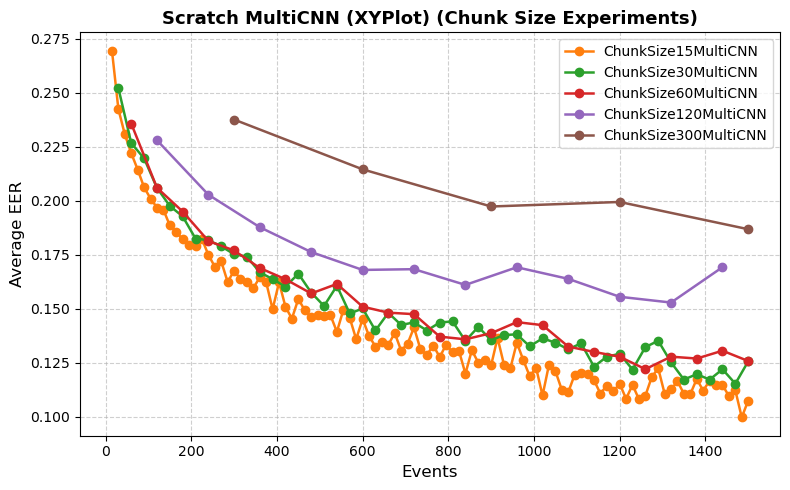

In [132]:
plot_chunk_json_curves("Visualization/CV/train_multi_CNN/XYPlot", max_event=1500, model="Scratch MultiCNN (XYPlot)")

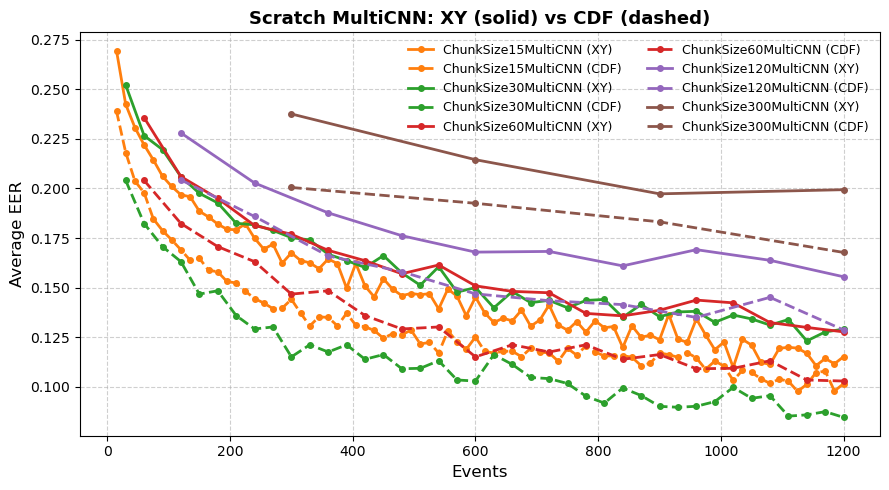

In [133]:
plot_chunk_xy_cdf_curves(
    xy_dir="Visualization/CV/train_multi_CNN/XYPlot",
    cdf_dir="Visualization/CV/train_multi_CNN/cdf",
    title="Scratch MultiCNN: XY (solid) vs CDF (dashed)",
    max_event=1200
)

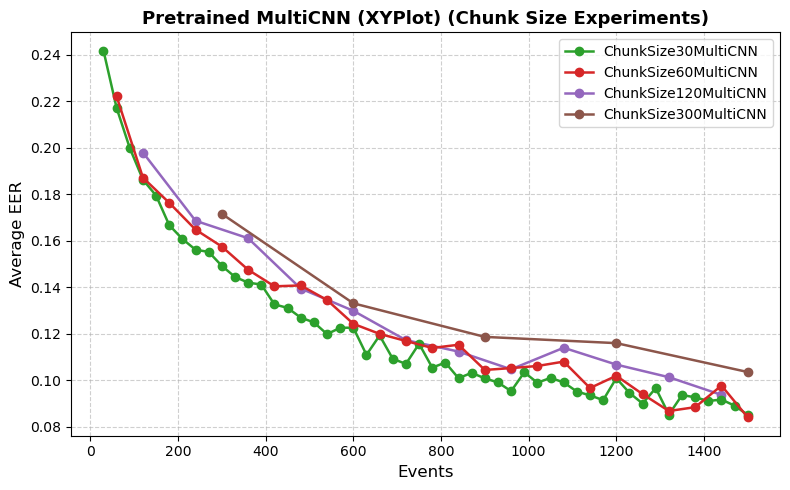

In [134]:
plot_chunk_json_curves("Visualization/Testing_pixel_vs_chunk", max_event=1500, model="Pretrained MultiCNN (XYPlot)")

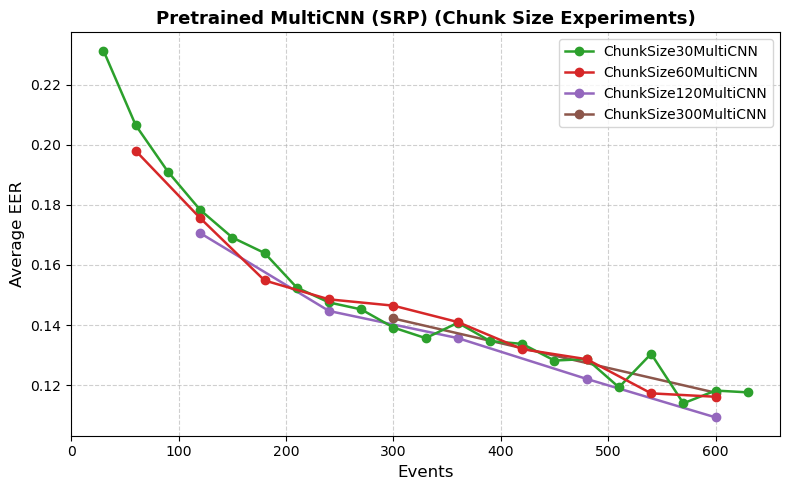

In [135]:
plot_chunk_json_curves("Visualization/Testing_pixel_vs_chunk_SRP", max_event=650, model="Pretrained MultiCNN (SRP)")

## XYPlot + CDF

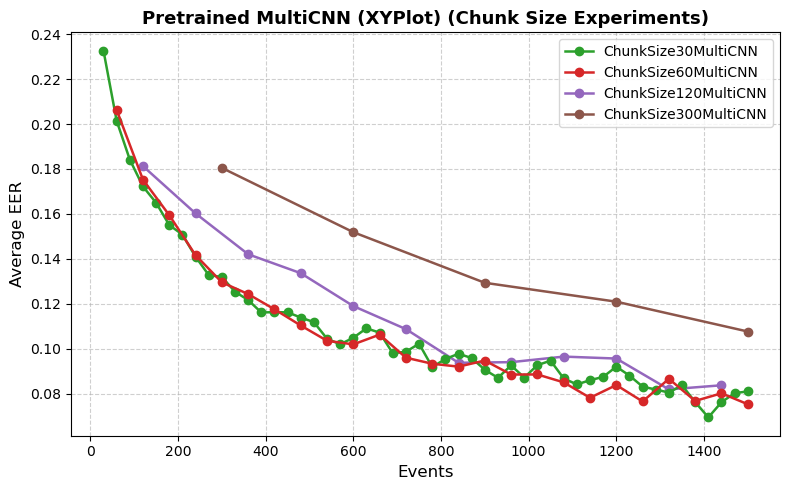

In [136]:
plot_chunk_json_curves("Visualization/Test/XYPlot", max_event=1500, model="Pretrained MultiCNN (XYPlot)")

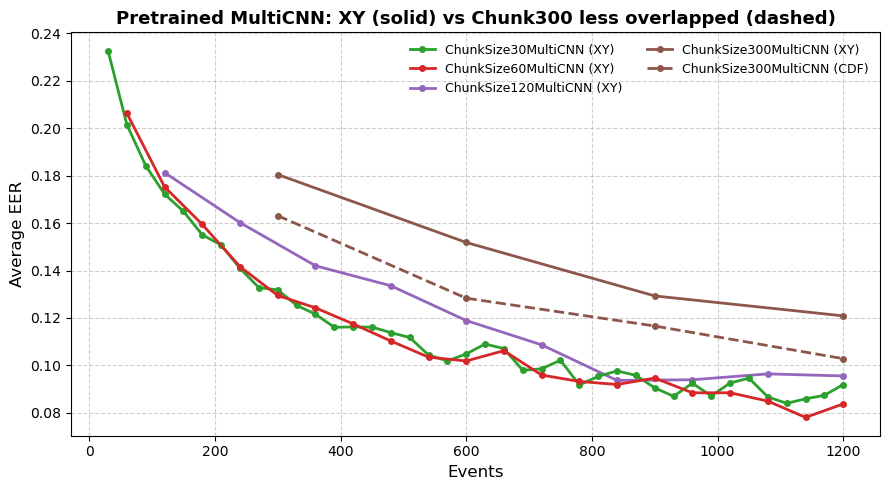

In [137]:
plot_chunk_xy_cdf_curves(
    xy_dir="Visualization/Test/XYPlot",
    cdf_dir="Visualization/Test/XYPlot_",
    title="Pretrained MultiCNN: XY (solid) vs Chunk300 less overlapped (dashed)",
    max_event=1200
)

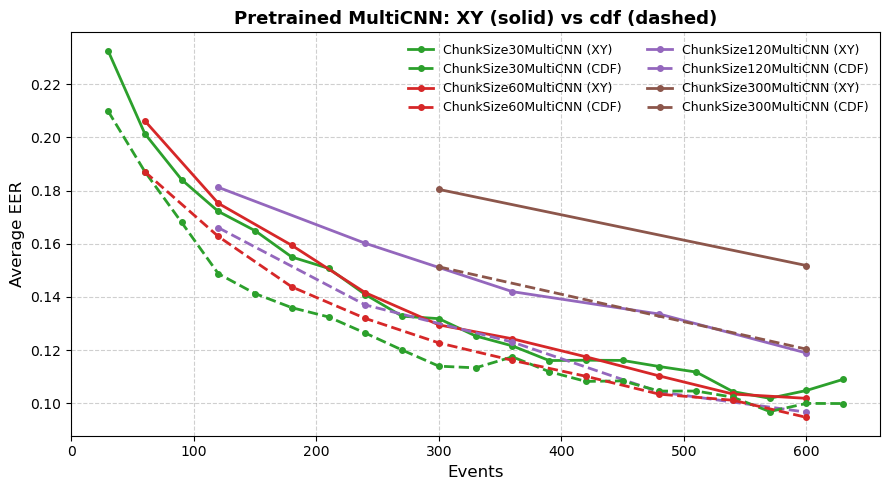

In [138]:
plot_chunk_xy_cdf_curves(
    xy_dir="Visualization/Test/XYPlot",
    cdf_dir="Visualization/Test/cdf",
    title="Pretrained MultiCNN: XY (solid) vs cdf (dashed)",
    max_event=650
)

In [139]:
from statistics_things.wilcoxon_curve_compare import wilcoxon_curve_test

json_xy = "Visualization/Test/per-user_XYPlot/ChunkSize30MultiCNN.json"
json_cdf = "Visualization/Test/per-user_cdf/ChunkSize30MultiCNN.json"

n_targets = [i+1 for i in range(20)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="XYPlot",
    label_b="CDF",
    alpha=0.05
)

df


,Comparison,n,Users,Mean EER (XYPlot),Mean EER (CDF),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,XYPlot vs CDF,1,10,23.27,20.99,2.27,0.083984,False
1,XYPlot vs CDF,2,10,20.15,18.72,1.43,0.105469,False
2,XYPlot vs CDF,3,10,18.42,16.81,1.61,0.083984,False
3,XYPlot vs CDF,4,10,17.22,14.88,2.34,0.109745,False
4,XYPlot vs CDF,5,10,16.49,14.13,2.37,0.109745,False
5,XYPlot vs CDF,6,10,15.50,13.60,1.90,0.109745,False
6,XYPlot vs CDF,7,10,15.08,13.25,1.83,0.109745,False
7,XYPlot vs CDF,8,10,14.09,12.64,1.45,0.262618,False
8,XYPlot vs CDF,9,10,13.28,12.01,1.27,0.207578,False
9,XYPlot vs CDF,10,10,13.18,11.40,1.79,0.123485,False


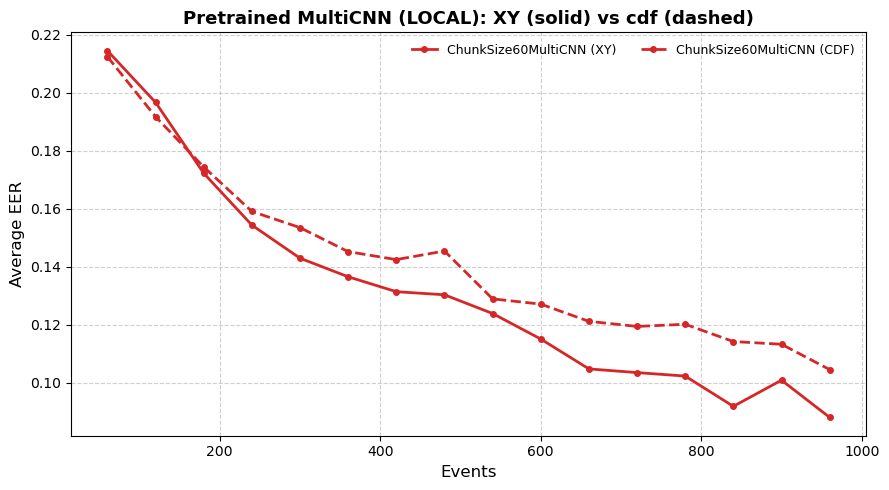

In [140]:
plot_chunk_xy_cdf_curves(
    xy_dir="Visualization/Pretrained/XYPlot",
    cdf_dir="Visualization/Pretrained/cdf",
    title="Pretrained MultiCNN (LOCAL): XY (solid) vs cdf (dashed)",
    max_event=1000
)

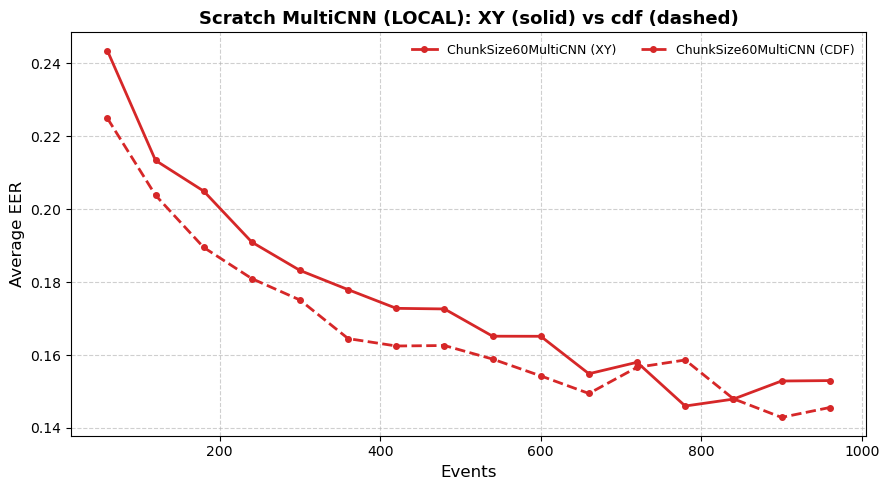

In [141]:
plot_chunk_xy_cdf_curves(
    xy_dir="Visualization/Scratch/XYPlot",
    cdf_dir="Visualization/Scratch/cdf",
    title="Scratch MultiCNN (LOCAL): XY (solid) vs cdf (dashed)",
    max_event=1000
)

## Protocol 1

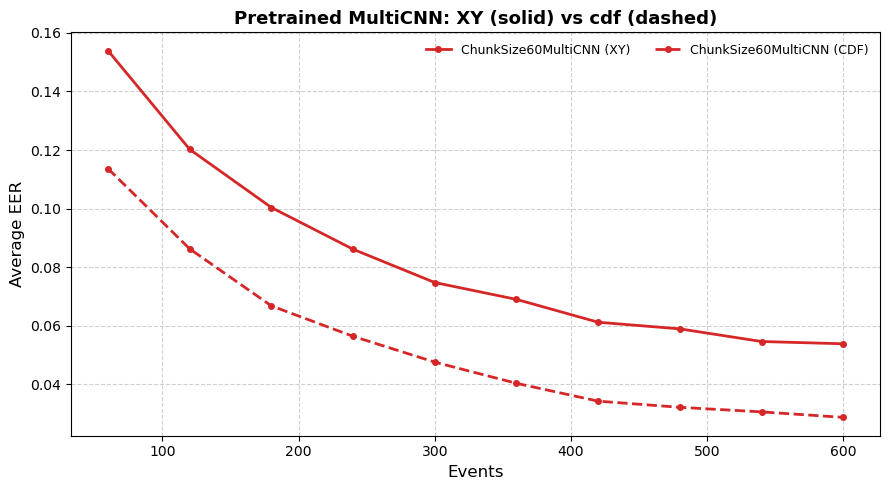

In [142]:
plot_chunk_xy_cdf_curves(
    xy_dir="Visualization/protocol1/XYPlot",
    cdf_dir="Visualization/protocol1/cdf",
    title="Pretrained MultiCNN: XY (solid) vs cdf (dashed)",
    max_event=650
)

In [143]:
from statistics_things.wilcoxon_curve_compare import wilcoxon_curve_test

json_xy = "Visualization/protocol1/per-user_XYPlot/ChunkSize60MultiCNN.json"
json_cdf = "Visualization/protocol1/per-user_cdf/ChunkSize60MultiCNN.json"

n_targets = [i+1 for i in range(30)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="XYPlot",
    label_b="CDF",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (XYPlot),Mean EER (CDF),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,XYPlot vs CDF,1,10,15.39,11.36,4.03,0.001953,True
1,XYPlot vs CDF,2,10,12.02,8.63,3.39,0.001953,True
2,XYPlot vs CDF,3,10,10.04,6.68,3.36,0.005859,True
3,XYPlot vs CDF,4,10,8.61,5.64,2.97,0.009766,True
4,XYPlot vs CDF,5,10,7.48,4.76,2.72,0.003906,True
5,XYPlot vs CDF,6,10,6.90,4.04,2.86,0.003906,True
6,XYPlot vs CDF,7,10,6.12,3.43,2.69,0.001953,True
7,XYPlot vs CDF,8,10,5.90,3.22,2.68,0.003906,True
8,XYPlot vs CDF,9,10,5.47,3.06,2.40,0.001953,True
9,XYPlot vs CDF,10,10,5.39,2.88,2.51,0.001953,True


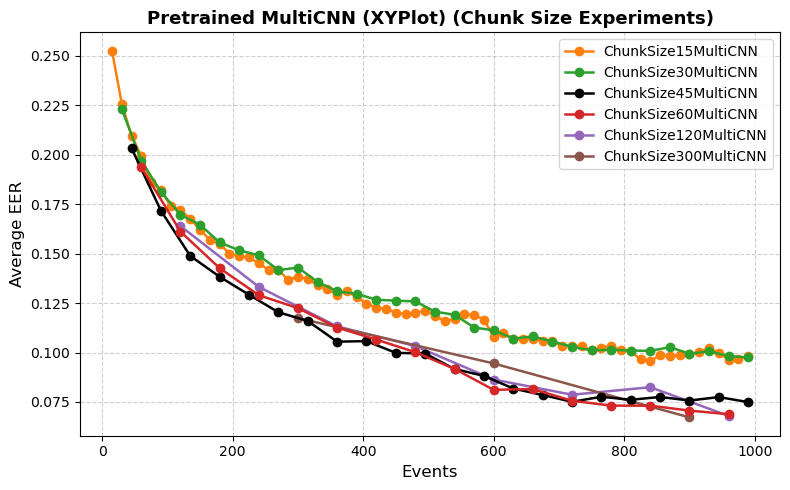

In [144]:
plot_chunk_json_curves("Visualization/global_scale_version/Pretrained_multi_CNN/XYPlot", max_event=1000, model="Pretrained MultiCNN (XYPlot)")

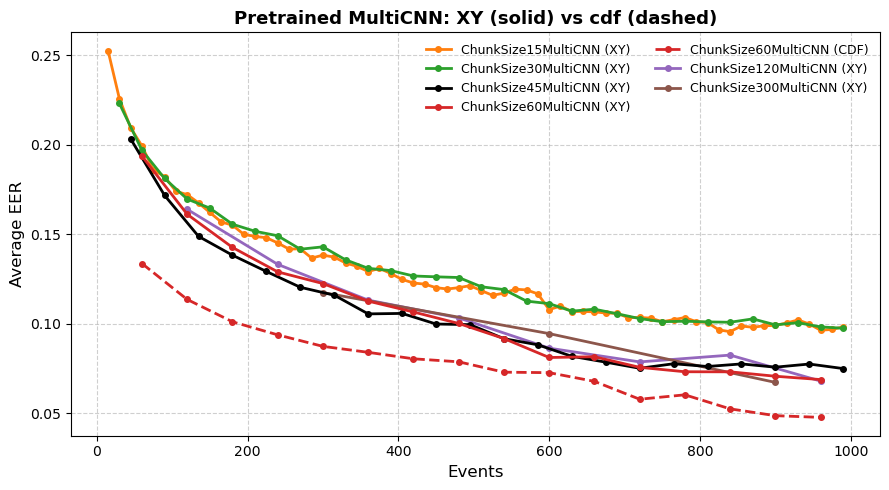

In [145]:
plot_chunk_xy_cdf_curves(
    xy_dir="Visualization/global_scale_version/Pretrained_multi_CNN/XYPlot",
    cdf_dir="Visualization/global_scale_version/Pretrained_multi_CNN/cdf",
    title="Pretrained MultiCNN: XY (solid) vs cdf (dashed)",
    max_event=1000
)

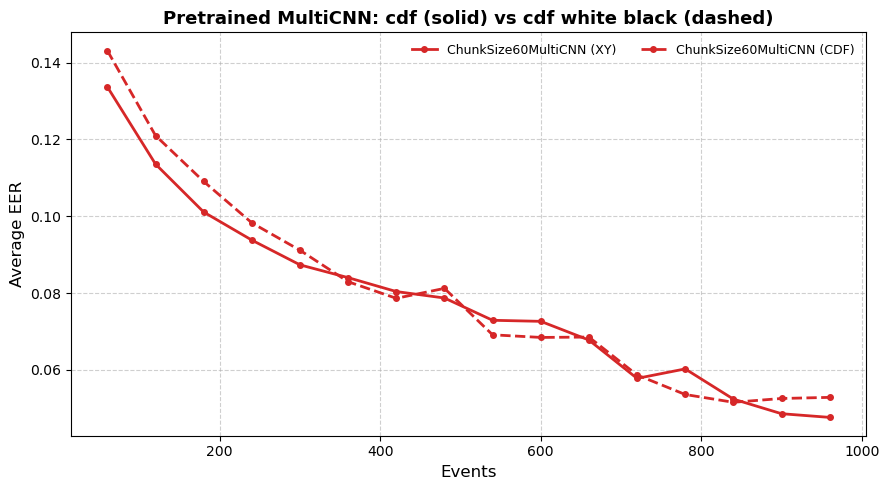

In [146]:
plot_chunk_xy_cdf_curves(
    xy_dir="Visualization/global_scale_version/Pretrained_multi_CNN/cdf",
    cdf_dir="Visualization/global_scale_version/Pretrained_multi_CNN/cdf_wb",
    title="Pretrained MultiCNN: cdf (solid) vs cdf white black (dashed)",
    max_event=1000
)

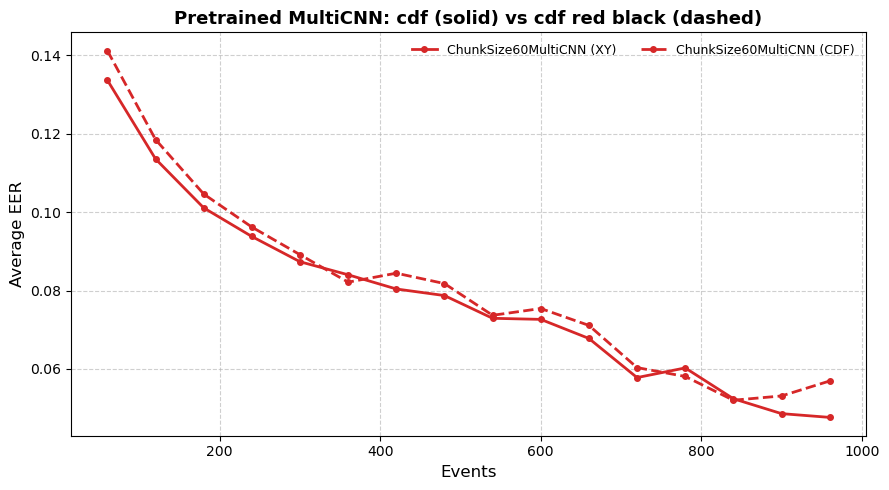

In [160]:
plot_chunk_xy_cdf_curves(
    xy_dir="Visualization/global_scale_version/Pretrained_multi_CNN/cdf",
    cdf_dir="Visualization/global_scale_version/Pretrained_multi_CNN/cdf_rb",
    title="Pretrained MultiCNN: cdf (solid) vs cdf red black (dashed)",
    max_event=1000
)

In [148]:
json_xy = "Visualization/global_scale_version/Pretrained_multi_CNN/per-user_XYPlot/ChunkSize60MultiCNN.json"
json_cdf = "Visualization/global_scale_version/Pretrained_multi_CNN/per-user_cdf/ChunkSize60MultiCNN.json"

n_targets = [i+1 for i in range(30)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="XYPlot",
    label_b="CDF",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (XYPlot),Mean EER (CDF),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,XYPlot vs CDF,1,10,19.37,13.37,6.01,0.001953,True
1,XYPlot vs CDF,2,10,16.12,11.36,4.76,0.001953,True
2,XYPlot vs CDF,3,10,14.27,10.11,4.16,0.001953,True
3,XYPlot vs CDF,4,10,12.90,9.38,3.52,0.003906,True
4,XYPlot vs CDF,5,10,12.25,8.73,3.51,0.001953,True
5,XYPlot vs CDF,6,10,11.26,8.40,2.86,0.009766,True
6,XYPlot vs CDF,7,10,10.66,8.04,2.62,0.037109,True
7,XYPlot vs CDF,8,10,10.01,7.87,2.14,0.083984,False
8,XYPlot vs CDF,9,10,9.17,7.29,1.88,0.083984,False
9,XYPlot vs CDF,10,10,8.11,7.26,0.85,0.556641,False


## SRP

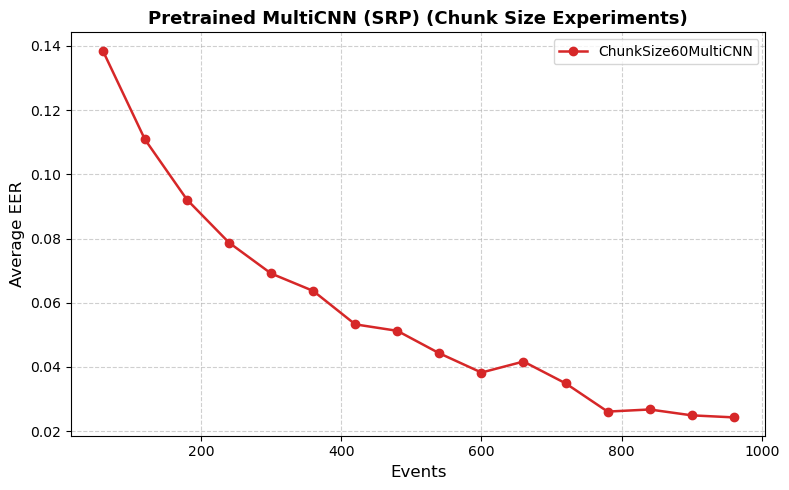

In [149]:
plot_chunk_json_curves("Results/Pretrained_MultiCNN/SRP/OneChannel", max_event=1000, model="Pretrained MultiCNN (SRP)")

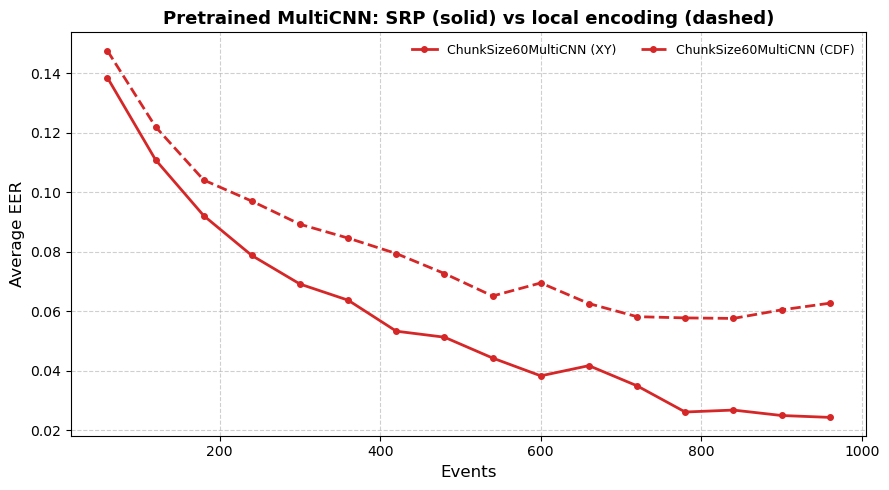

In [150]:
plot_chunk_xy_cdf_curves(
    xy_dir="Results/Pretrained_MultiCNN/SRP/OneChannel",
    cdf_dir="Results/Pretrained_MultiCNN/SRP/MultiChannel",
    title="Pretrained MultiCNN: SRP (solid) vs local encoding (dashed)",
    max_event=1000
)

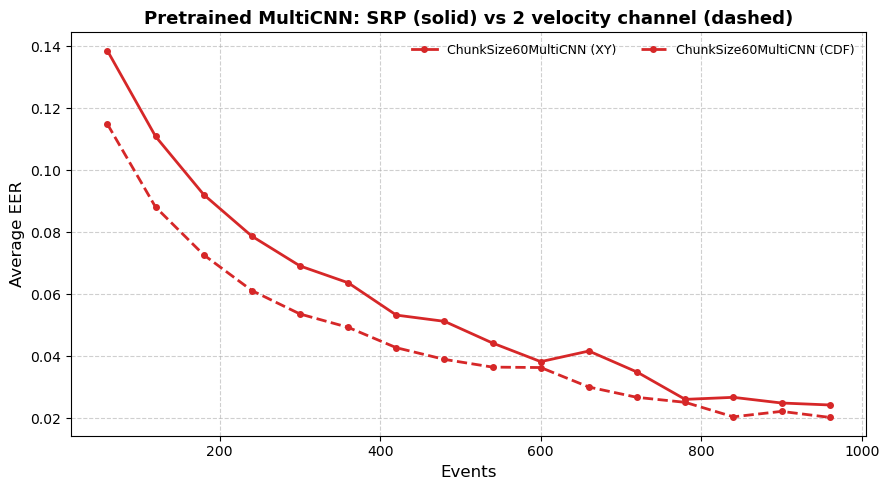

In [151]:
plot_chunk_xy_cdf_curves(
    xy_dir="Results/Pretrained_MultiCNN/SRP/OneChannel",
    cdf_dir="Results/Pretrained_MultiCNN/SRP/VelocityChannel",
    title="Pretrained MultiCNN: SRP (solid) vs 2 velocity channel (dashed)",
    max_event=1000
)

In [152]:
json_xy = "Results/Pretrained_MultiCNN/SRP/per-userOneChannel/ChunkSize60MultiCNN.json"
json_cdf = "Results/Pretrained_MultiCNN/SRP/per-userVelocityChannel/ChunkSize60MultiCNN.json"

n_targets = [i+1 for i in range(15)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="XYPlot",
    label_b="CDF",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (XYPlot),Mean EER (CDF),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,XYPlot vs CDF,1,10,13.85,11.48,2.37,0.001953,True
1,XYPlot vs CDF,2,10,11.09,8.81,2.28,0.001953,True
2,XYPlot vs CDF,3,10,9.21,7.27,1.94,0.001953,True
3,XYPlot vs CDF,4,10,7.87,6.12,1.75,0.019531,True
4,XYPlot vs CDF,5,10,6.91,5.36,1.55,0.019531,True
5,XYPlot vs CDF,6,10,6.37,4.93,1.44,0.050612,False
6,XYPlot vs CDF,7,10,5.32,4.27,1.05,0.066316,False
7,XYPlot vs CDF,8,10,5.12,3.90,1.23,0.028402,True
8,XYPlot vs CDF,9,10,4.42,3.65,0.78,0.374259,False
9,XYPlot vs CDF,10,10,3.82,3.63,0.19,0.858955,False


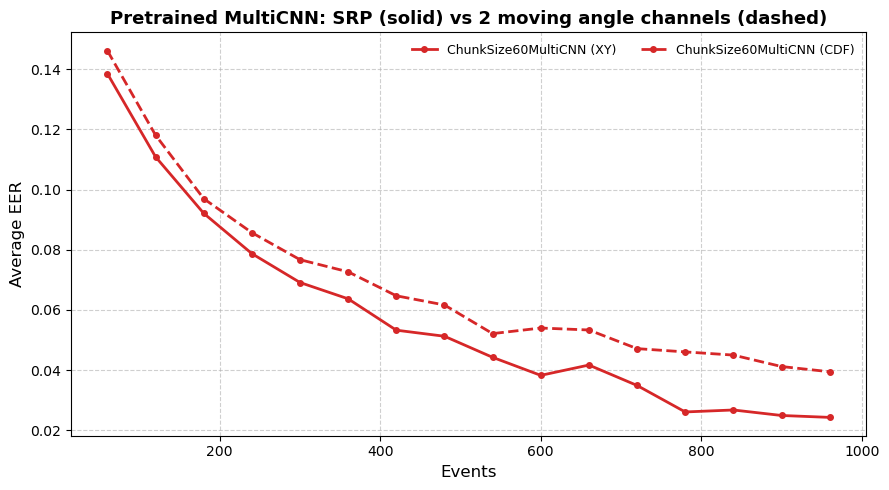

In [153]:
plot_chunk_xy_cdf_curves(
    xy_dir="Results/Pretrained_MultiCNN/SRP/OneChannel",
    cdf_dir="Results/Pretrained_MultiCNN/SRP/AngleChannel",
    title="Pretrained MultiCNN: SRP (solid) vs 2 moving angle channels (dashed)",
    max_event=1000
)

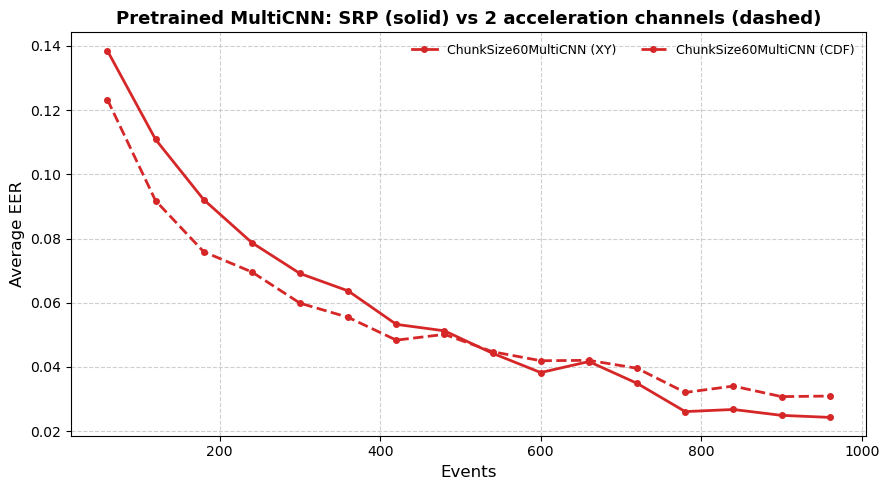

In [154]:
plot_chunk_xy_cdf_curves(
    xy_dir="Results/Pretrained_MultiCNN/SRP/OneChannel",
    cdf_dir="Results/Pretrained_MultiCNN/SRP/AccelerationChannel",
    title="Pretrained MultiCNN: SRP (solid) vs 2 acceleration channels (dashed)",
    max_event=1000
)

In [155]:
json_xy = "Results/Pretrained_MultiCNN/SRP/per-userOneChannel/ChunkSize60MultiCNN.json"
json_cdf = "Results/Pretrained_MultiCNN/SRP/per-userAccelerationChannel/ChunkSize60MultiCNN.json"

n_targets = [i+1 for i in range(15)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="XYPlot",
    label_b="CDF",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (XYPlot),Mean EER (CDF),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,XYPlot vs CDF,1,10,13.85,12.33,1.52,0.027344,True
1,XYPlot vs CDF,2,10,11.09,9.18,1.91,0.009766,True
2,XYPlot vs CDF,3,10,9.21,7.59,1.62,0.037109,True
3,XYPlot vs CDF,4,10,7.87,6.96,0.91,0.375000,False
4,XYPlot vs CDF,5,10,6.91,5.99,0.92,0.232422,False
5,XYPlot vs CDF,6,10,6.37,5.54,0.82,0.441268,False
6,XYPlot vs CDF,7,10,5.32,4.83,0.49,0.575403,False
7,XYPlot vs CDF,8,10,5.12,5.01,0.11,0.593955,False
8,XYPlot vs CDF,9,10,4.42,4.47,0.05,0.952765,False
9,XYPlot vs CDF,10,10,3.82,4.19,0.37,0.374259,False


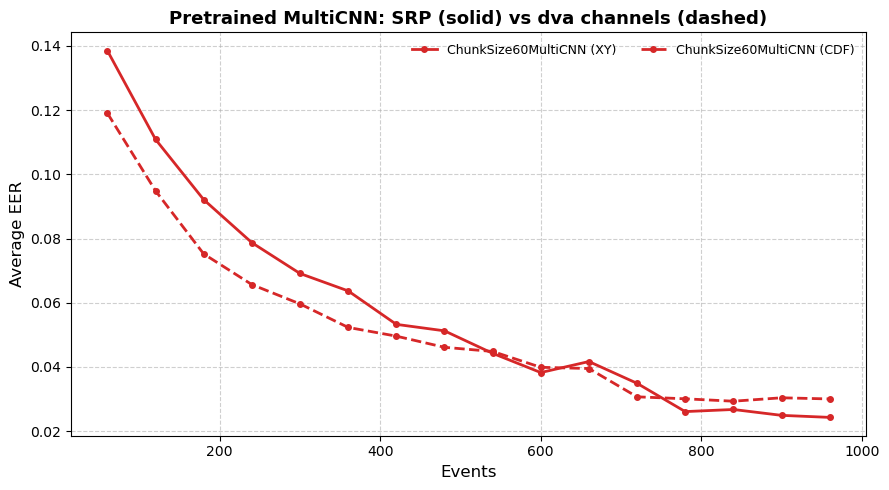

In [156]:
plot_chunk_xy_cdf_curves(
    xy_dir="Results/Pretrained_MultiCNN/SRP/OneChannel",
    cdf_dir="Results/Pretrained_MultiCNN/SRP/dvaChannel",
    title="Pretrained MultiCNN: SRP (solid) vs dva channels (dashed)",
    max_event=1000
)

In [157]:
json_xy = "Results/Pretrained_MultiCNN/SRP/per-userOneChannel/ChunkSize60MultiCNN.json"
json_cdf = "Results/Pretrained_MultiCNN/SRP/per-userdvaChannel/ChunkSize60MultiCNN.json"

n_targets = [i+1 for i in range(15)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="XYPlot",
    label_b="CDF",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (XYPlot),Mean EER (CDF),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,XYPlot vs CDF,1,10,13.85,11.91,1.95,0.009766,True
1,XYPlot vs CDF,2,10,11.09,9.49,1.60,0.009766,True
2,XYPlot vs CDF,3,10,9.21,7.52,1.69,0.005859,True
3,XYPlot vs CDF,4,10,7.87,6.56,1.31,0.064453,False
4,XYPlot vs CDF,5,10,6.91,5.96,0.95,0.064453,False
5,XYPlot vs CDF,6,10,6.37,5.23,1.14,0.138641,False
6,XYPlot vs CDF,7,10,5.32,4.96,0.37,0.767097,False
7,XYPlot vs CDF,8,10,5.12,4.61,0.51,0.441268,False
8,XYPlot vs CDF,9,10,4.42,4.48,0.06,0.514670,False
9,XYPlot vs CDF,10,10,3.82,3.99,0.16,0.593955,False


## Scratch MultiCNN


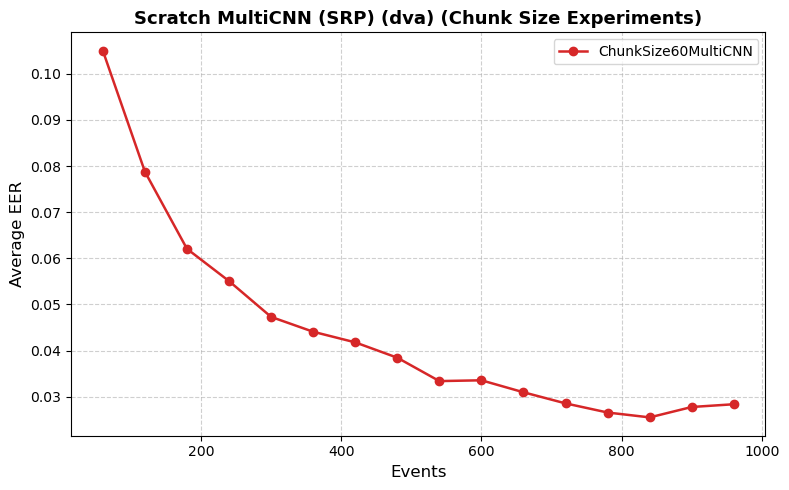

In [158]:
plot_chunk_json_curves("Results/Scratch_MultiCNN/SRP/dvaChannel", max_event=1000, model="Scratch MultiCNN (SRP) (dva)")

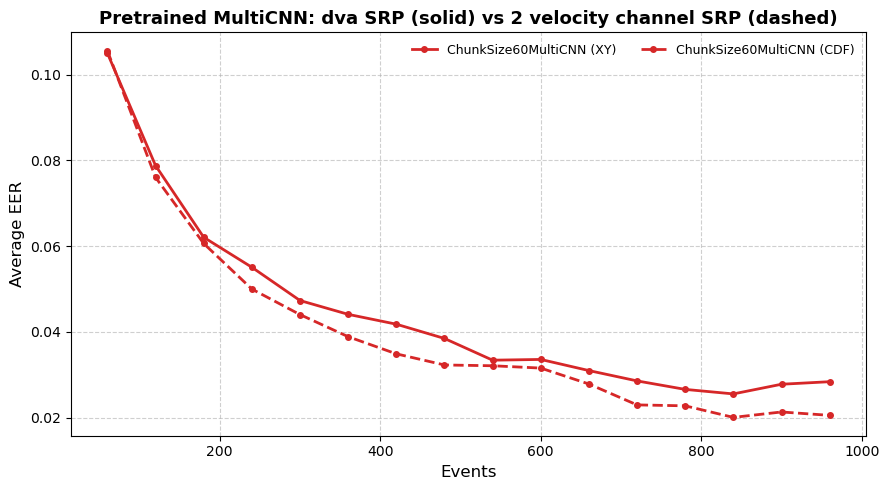

In [159]:
plot_chunk_xy_cdf_curves(
    xy_dir="Results/Scratch_MultiCNN/SRP/dvaChannel",
    cdf_dir="Results/Scratch_MultiCNN/SRP/VelocityChannel",
    title="Pretrained MultiCNN: dva SRP (solid) vs 2 velocity channel SRP (dashed)",
    max_event=1000
)